# Ray Tracing, Irradiance, and Polarization Analysis

Having modeled the extended LED source, I now turn to ray tracing the rays from this source. The purpose is to understand what degree of uniformity we can expect in the the irradiance after the illuminator. 

The algorithms and lens developed in the previous sections have been incorporated into the `main` module.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import optiland.backend as be
from optiland.coatings import BaseCoatingPolarized
from optiland.jones import JonesPolarizerH, JonesQuarterWaveRetarder
from optiland.rays import PolarizationState, PolarizedRays

from main import Collimator, LED, beam_radius, irradiance_map, stokes_map


# Number of rays to trace
num_rays = 100_000


class LinearPolarizer(BaseCoatingPolarized):
    def __init__(self) -> None:
        super().__init__()
        self.jones = JonesPolarizerH()


class QuarterWavePlate(BaseCoatingPolarized):
    def __init__(self, theta: float = 0.0) -> None:
        super().__init__()
        self.jones = JonesQuarterWaveRetarder(theta=theta)


led = LED()

lens = Collimator()
lens.set_polarization(PolarizationState(is_polarized=False))


# The polarizer is at 5 cm from the collimator to account for tube length.
# The quarter-wave plate is 2 cm after the polarizer.
lens.set_thickness(50.0, surface_number=2)
lens.add_surface(index=3, thickness=20.0, material="air")
lens.add_surface(index=4, thickness=0.0, material="air")

lens.surface_group.surfaces[3].interaction_model.coating = LinearPolarizer()
lens.surface_group.surfaces[4].interaction_model.coating = QuarterWavePlate(theta=np.pi / 4)

led_rays = led.generate_rays(num_rays=num_rays)

# Shift rays to start at the z-position of the source, not the collimator's front vertex.
z_offset = lens.surface_group.positions[0, 0]
rays = PolarizedRays(
    led_rays.x,
    led_rays.y,
    led_rays.z + z_offset,
    led_rays.L,
    led_rays.M,
    led_rays.N,
    led_rays.i,
    led_rays.w,
)

lens.surface_group.trace(rays)
rays.update_intensity(lens.polarization_state)

/home/kmd/src/projects/polarized-led-illuminator/.venv/lib/python3.13/site-packages/optiland/geometries/even_asphere.py:105: RuntimeWarning: invalid value encountered in sqrt
  z = r2 / (self.radius * (1 + be.sqrt(1 - (1 + self.k) * r2 / self.radius**2)))
/home/kmd/src/projects/polarized-led-illuminator/.venv/lib/python3.13/site-packages/optiland/geometries/even_asphere.py:126: RuntimeWarning: invalid value encountered in sqrt
  denom = self.radius * be.sqrt(1 - (1 + self.k) * r2 / self.radius**2)


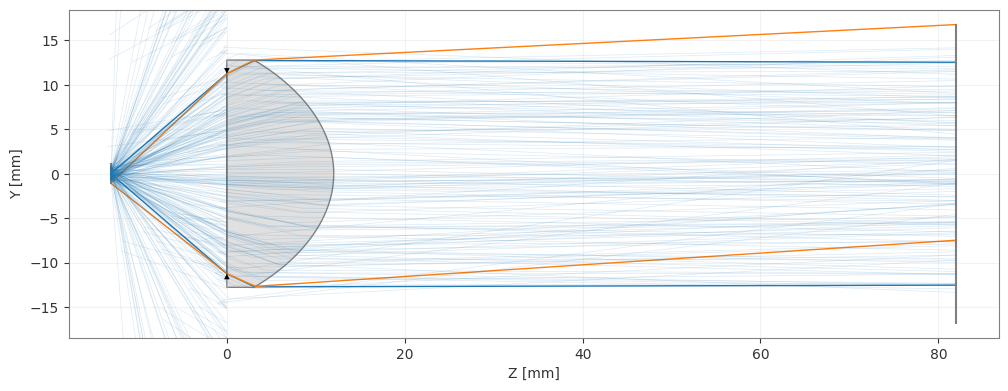

In [2]:
x_hist = be.to_numpy(lens.surface_group.x)   # (num_surfaces, num_rays)
y_hist = be.to_numpy(lens.surface_group.y)
z_hist = be.to_numpy(lens.surface_group.z)
i_hist = be.to_numpy(lens.surface_group.intensity)

# Subsample rays
rng = np.random.default_rng(0)
idx = rng.choice(x_hist.shape[1], size=256, replace=False)

# Draw just the system geometry (one dummy ray bundle, we'll overlay the real rays).
fig, ax = lens.draw(fields="all", num_rays=2, distribution="line_y", figsize=(12, 5))

for k in idx:
    yk, zk, ik = y_hist[:, k].copy(), z_hist[:, k].copy(), i_hist[:, k]
    yk[ik == 0] = np.nan   # break the line where the ray was blocked/vignetted
    zk[ik == 0] = np.nan
    ax.plot(zk, yk, color="C0", alpha=0.15, linewidth=0.5)

## Irradiance vs. Distance

Having traced the rays, I now look at how the irradiance and polarization state evolves over distance from the illuminator.

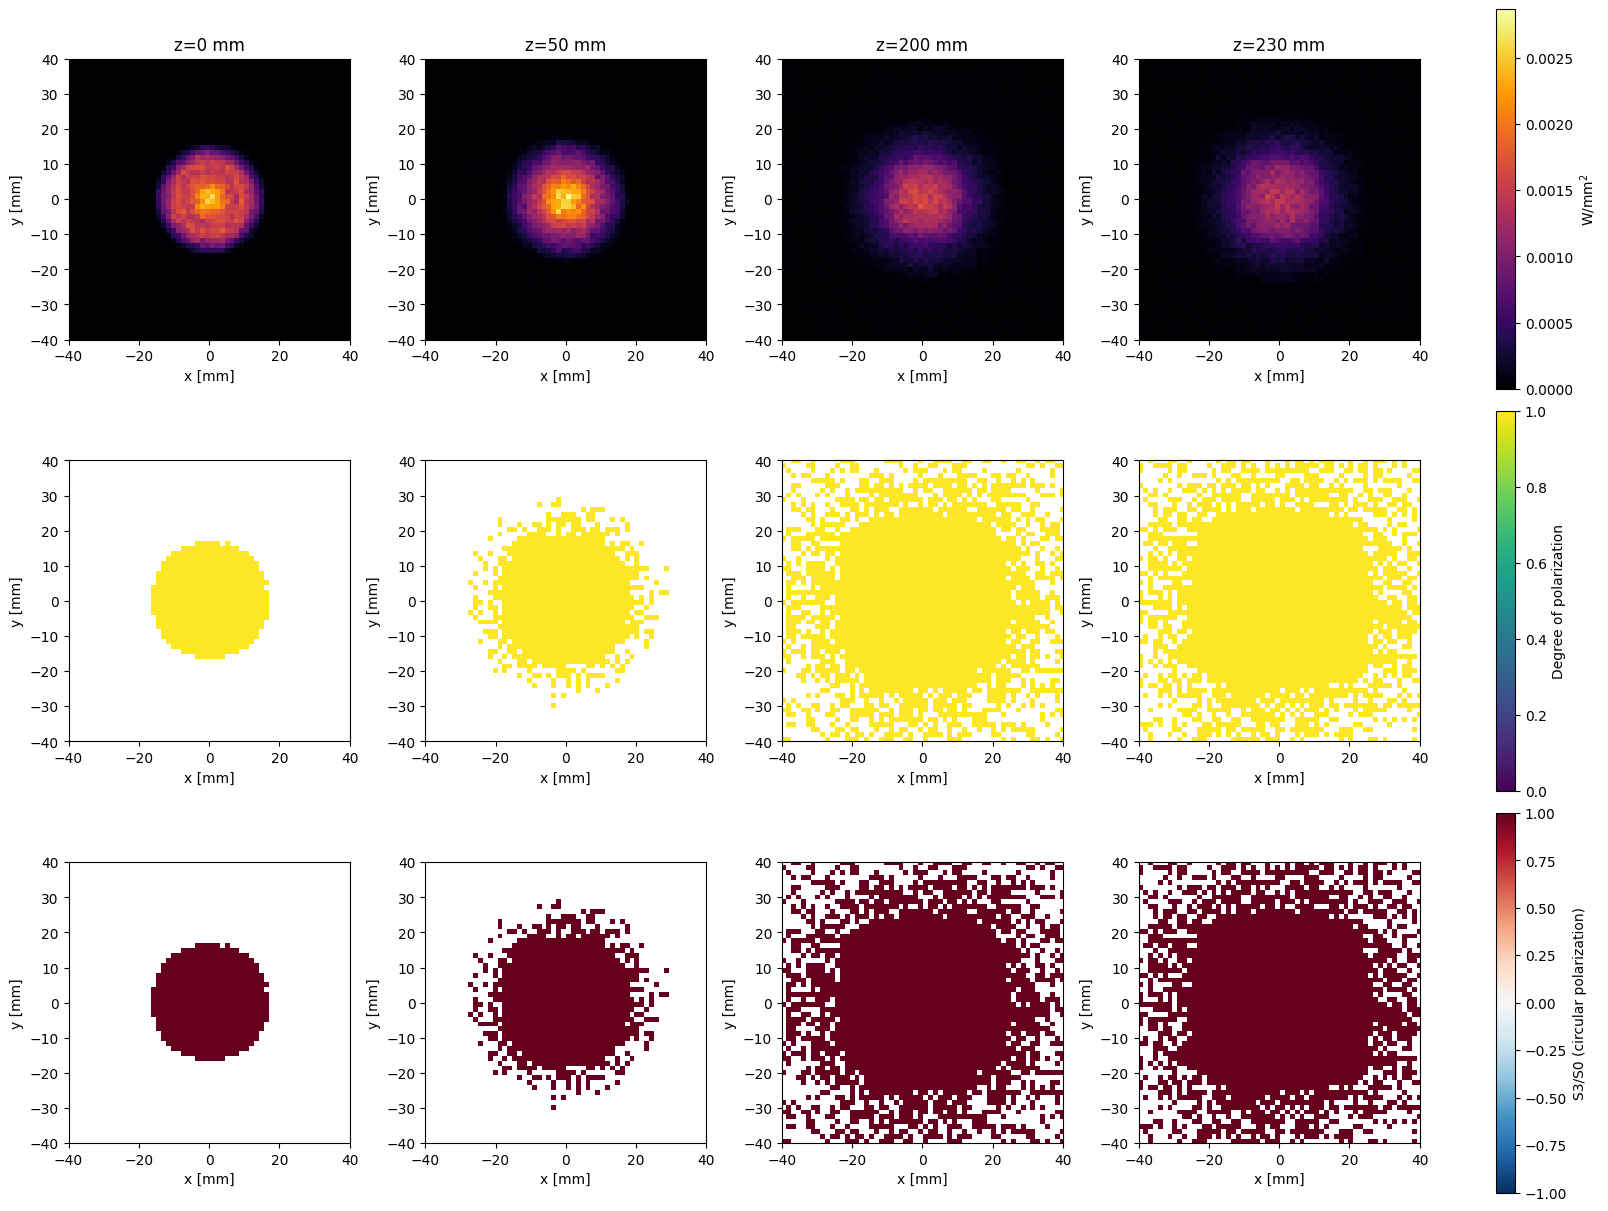

In [3]:
# QWP sits at z ~= 82.0163 mm (coincident with the image plane). Read the z
# straight off `rays` (not `lens.surface_group`, which lens.draw() above
# re-traces and overwrites with its own field-point ray bundle) and use
# nanmedian since vignetted rays carry NaN z.
z_qwp = float(np.nanmedian(be.to_numpy(rays.z)))
z_planes = [z_qwp, z_qwp + 50, z_qwp + 200, z_qwp + 230]

r_max = beam_radius(rays, z_planes[-1])
extent = (-r_max, r_max, -r_max, r_max)

# Precompute all irradiance + Stokes maps first so every subplot in a row can
# share one vmax and one colorbar for the whole row.
irr_maps = [irradiance_map(rays, z, extent=extent) for z in z_planes]
irr_vmax = max(irr.max() for irr, _, _ in irr_maps)
stokes_maps = [stokes_map(rays, z, extent=extent) for z in z_planes]

# constrained_layout (instead of a trailing fig.tight_layout()) accounts for
# the shared colorbars' reserved space, so they don't overlap the last plot.
fig, axes = plt.subplots(3, len(z_planes), figsize=(4 * len(z_planes), 12), constrained_layout=True)
for col, z in enumerate(z_planes):
    irr, xe, ye = irr_maps[col]
    im0 = axes[0, col].imshow(
        irr.T, origin="lower", extent=(xe[0], xe[-1], ye[0], ye[-1]),
        cmap="inferno", vmin=0, vmax=irr_vmax,
    )
    axes[0, col].set_title(f"z={z - z_qwp:.0f} mm")
    axes[0, col].set_xlabel("x [mm]")
    axes[0, col].set_ylabel("y [mm]")
    axes[0, col].set_xlim(-40, 40)
    axes[0, col].set_ylim(-40, 40)

    S0m, S1m, S2m, S3m, xe, ye = stokes_maps[col]
    dop = np.sqrt(S1m**2 + S2m**2 + S3m**2) / np.where(S0m > 0, S0m, np.nan)
    im1 = axes[1, col].imshow(
        dop.T, origin="lower", extent=(xe[0], xe[-1], ye[0], ye[-1]), cmap="viridis", vmin=0, vmax=1
    )
    axes[1, col].set_xlabel("x [mm]")
    axes[1, col].set_ylabel("y [mm]")
    axes[1, col].set_xlim(-40, 40)
    axes[1, col].set_ylim(-40, 40)

    # Circular polarization state: S3/S0, +1 = fully right-circular,
    # -1 = fully left-circular, 0 = no circular component.
    circ = S3m / np.where(S0m > 0, S0m, np.nan)
    im2 = axes[2, col].imshow(
        circ.T, origin="lower", extent=(xe[0], xe[-1], ye[0], ye[-1]), cmap="RdBu_r", vmin=-1, vmax=1
    )
    axes[2, col].set_xlabel("x [mm]")
    axes[2, col].set_ylabel("y [mm]")
    axes[2, col].set_xlim(-40, 40)
    axes[2, col].set_ylim(-40, 40)

# One shared colorbar per row, to the right of the right-most plot, instead
# of one per subplot.
fig.colorbar(im0, ax=axes[0, :], label="W/mm$^2$")
fig.colorbar(im1, ax=axes[1, :], label="Degree of polarization")
fig.colorbar(im2, ax=axes[2, :], label="S3/S0 (circular polarization)")

plt.show()

In [4]:
print("Average degree of polarization:", np.mean(dop[~np.isnan(dop)]))
print("Average circular polarization:", np.mean(circ[~np.isnan(circ)]))

Average degree of polarization: 0.9999991839265064
Average circular polarization: 0.9998293160717984


The above plot shows the irradiance, degree of polarization, and degree of circular polarization as a function of axial distance from the quarter waveplate. There are a few interesting things to note:

1. An image of the LED emitter surface begins to emerge at a distance of about 20 cm from the system. This is a well-known property of LED collimators; the collimator maps source position to angle, and as we increase the axial distance of a transverse observation plane, a single (x, y) point in the plane maps to angle.
2. The degree of polarization and degree of circular polarization are near perfect. In reality, a real polarizer may only result in a DoP of 0.01.
3. After a distance of about 20 cm, the irradiance is very roughly constant over the cross section and axial extent of of the cuvette (10 mm x 10 mm x 30 mm, long axis along z). Since the proteins are quick to transition to the active state and slow to relax, this is likely more than sufficient for my colleague's purposes. (Recall that extremely little blue light will activate nearly all the proteins in the cuvette in at most a few milliseconds, whereas they require seconds or more to relax.)

## Varying the LED-Asphere Distance

One thing to note is that the LED actually does not lie in the paraxial focal plane of the asphere.

In [5]:
print(f"LED distance from lens: {lens.surface_group.positions[0][0]}")
print(f"Paraxial front focal distance: {lens.paraxial.f1()}")

LED distance from lens: -13.0512
Paraxial front focal distance: -19.640009474777315


Let's try changing this distance to match the paraxial back focal distance and see what happens.

In [6]:
# The paraxial front focal distance is an intrinsic property of the
# asphere/B270 surfaces (surface indices 1, 2) alone, independent of where
# the object/LED actually sits, so we can read it off a fresh default
# Collimator before moving the LED.
f1 = Collimator().paraxial.f1()
print(f"Paraxial front focal distance: {f1:.4f} mm")

lens_ffd = Collimator()
lens_ffd.set_polarization(PolarizationState(is_polarized=False))

# Move the LED to sit exactly at the front focal point (f1 is negative,
# i.e. in front of the first surface; set_thickness takes a positive
# distance for the object surface).
lens_ffd.set_thickness(abs(f1), surface_number=0)

# The polarizer is at 5 cm from the collimator to account for tube length.
# The quarter-wave plate is 2 cm after the polarizer.
lens_ffd.set_thickness(50.0, surface_number=2)
lens_ffd.add_surface(index=3, thickness=20.0, material="air")
lens_ffd.add_surface(index=4, thickness=0.0, material="air")

lens_ffd.surface_group.surfaces[3].interaction_model.coating = LinearPolarizer()
lens_ffd.surface_group.surfaces[4].interaction_model.coating = QuarterWavePlate(theta=np.pi / 4)

led_rays_ffd = led.generate_rays(num_rays=num_rays)

# Shift rays to start at the z-position of the source, not the collimator's front vertex.
z_offset_ffd = lens_ffd.surface_group.positions[0, 0]
rays_ffd = PolarizedRays(
    led_rays_ffd.x,
    led_rays_ffd.y,
    led_rays_ffd.z + z_offset_ffd,
    led_rays_ffd.L,
    led_rays_ffd.M,
    led_rays_ffd.N,
    led_rays_ffd.i,
    led_rays_ffd.w,
)

lens_ffd.surface_group.trace(rays_ffd)
rays_ffd.update_intensity(lens_ffd.polarization_state)

Paraxial front focal distance: -19.6400 mm


/home/kmd/src/projects/polarized-led-illuminator/.venv/lib/python3.13/site-packages/optiland/geometries/even_asphere.py:105: RuntimeWarning: invalid value encountered in sqrt
  z = r2 / (self.radius * (1 + be.sqrt(1 - (1 + self.k) * r2 / self.radius**2)))
/home/kmd/src/projects/polarized-led-illuminator/.venv/lib/python3.13/site-packages/optiland/geometries/even_asphere.py:126: RuntimeWarning: invalid value encountered in sqrt
  denom = self.radius * be.sqrt(1 - (1 + self.k) * r2 / self.radius**2)


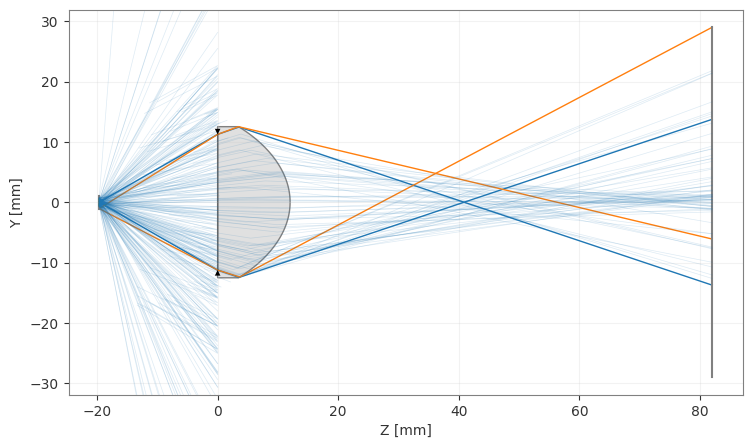

In [7]:
x_hist_ffd = be.to_numpy(lens_ffd.surface_group.x)   # (num_surfaces, num_rays)
y_hist_ffd = be.to_numpy(lens_ffd.surface_group.y)
z_hist_ffd = be.to_numpy(lens_ffd.surface_group.z)
i_hist_ffd = be.to_numpy(lens_ffd.surface_group.intensity)

# Subsample rays
rng = np.random.default_rng(0)
idx = rng.choice(x_hist_ffd.shape[1], size=256, replace=False)

# Draw just the system geometry (one dummy ray bundle, we'll overlay the real rays).
fig, ax = lens_ffd.draw(fields="all", num_rays=2, distribution="line_y", figsize=(12, 5))

for k in idx:
    yk, zk, ik = y_hist_ffd[:, k].copy(), z_hist_ffd[:, k].copy(), i_hist_ffd[:, k]
    yk[ik == 0] = np.nan   # break the line where the ray was blocked/vignetted
    zk[ik == 0] = np.nan
    ax.plot(zk, yk, color="C0", alpha=0.15, linewidth=0.5)

Above it's clear that, rather counter-intuitively, placing the LED at the front focal plane of the asphere results in the marginal rays focusing close to the lens, i.e. they are not at all collimated. This hightights the danger in using paraxial quantities when trying to collimate extended sources using high NA optics.